<a id='ContentList'></a>
# Content List

## Single to Single Generation 

### 1. [Text To Image](#TextToImage)

### 2. [Image To Text](#ImageToText)

### 3. [Text To Audio](#TextToAudio)

### 4. [Audio To Text](#AudioToText)

### 5. [Image To Audio](#ImageToAudio)

### 6. [Audio To Image](#AudioToImage)

### 7. [Text To Video](#TextToVideo)

### 8. [Video To Text](#VideoToText)

## Multi-Conditioning Generation

### 1. [Text + Image + Audio To Image](#TextImageAudioToImage)

## Joint Multimodal Generation

### 1. [Text To Image+Text](#TextToImageText)

### 2. [Text To Video+Audio](#TextToVideoAudio)

<a id='LoadModel'></a>
# Load Model

In [1]:
"""
Load model from checkpoint.

For model inference:
The outputs are stored in an array as [number of output modalities, number of samples]
If I generate 4 samples of image + caption, the shape would be [2, 4]
"""

import os
from core.models.model_module_infer import model_module

model_load_paths = ['CoDi_encoders.pth', 'CoDi_text_diffuser.pth', 'CoDi_audio_diffuser_m.pth', 'CoDi_video_diffuser_8frames.pth']
inference_tester = model_module(data_dir='checkpoints/', pth=model_load_paths, fp16=False) # turn on fp16=True if loading fp16 weights
inference_tester = inference_tester.cuda()
inference_tester = inference_tester.eval()



#######################
# Running in eps mode #
#######################

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Load pretrained weight from ['CoDi_encoders.pth', 'CoDi_text_diffuser.pth', 'CoDi_audio_diffuser_m.pth', 'CoDi_video_diffuser_8frames.pth']


<a id='TextToImage'></a>
# Text To Image
### [Back to Menu](#ContentList)

Data shape for DDIM sampling is [[1, 4, 32, 32]], eta 0.0


DDIM Sampler: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.09it/s]


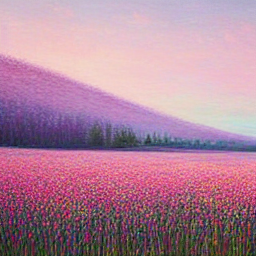

In [3]:
# Give a prompt
prompt = "A beautiful oil painting of a birch tree standing in a spring meadow with pink flowers, a distant mountain towers over the field in the distance. Artwork by Alena Aenami"

# Generate image
images = inference_tester.inference(
                xtype = ['image'],
                condition = [prompt],
                condition_types = ['text'],
                n_samples = 1, 
                image_size = 256,
                ddim_steps = 50)
images[0][0]

<a id='ImageToText'></a>
# Image To Text
### [Back to Menu](#ContentList)

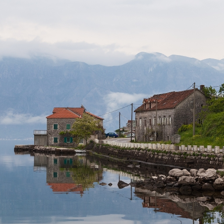

In [7]:
# Load an image input
from PIL import Image
im = Image.open('./assets/demo_files/house.jpeg').resize((224,224))
im

In [12]:
text = inference_tester.inference(
                xtype = ['text'],
                condition = [im],
                condition_types = ['image'],
                n_samples = 4, 
                ddim_steps = 50,
                scale = 7.5,)
text[0]

Data shape for DDIM sampling is [[4, 768]], eta 0.0


DDIM Sampler: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 17.30it/s]


['view of the sunset near the lake with two of the mountains in the distance with me on the back, a boat in the background.',
 'houses with a lake and in the lake',
 'hill with sunset near by in the river and lake',
 'scene near the lake with a castle next to it, near the tony mountain for the day']

<a id='TextToAudio'></a>
# Text To Audio
### [Back to Menu](#ContentList)

In [13]:
# Give a prompt
prompt = 'a train enters station.'

# Generate audio
audio_wave = inference_tester.inference(
                xtype = ['audio'],
                condition = [prompt],
                condition_types = ['text'],
                scale = 7.5,
                n_samples = 1, 
                ddim_steps = 50)[0]

# Play the audio
from IPython.display import Audio
Audio(audio_wave.squeeze(), rate=16000)

Data shape for DDIM sampling is [[1, 8, 256, 16]], eta 0.0


DDIM Sampler: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.18it/s]


<a id='AudioToText'></a>
# Audio To Text
### [Back to Menu](#ContentList)

In [3]:
import torchaudio
import torch
from IPython.display import Audio

path = './assets/demo_files/train_sound.flac'

audio_wavs, sr = torchaudio.load(path)
audio_wavs = torchaudio.functional.resample(waveform=audio_wavs, orig_freq=sr, new_freq=16000).mean(0)[:int(16000 * 10.23)]
Audio(audio_wavs.squeeze(), rate=16000)

In [4]:
n_samples = 4
text = inference_tester.inference(
                xtype = ['text'],
                condition = [audio_wavs],
                condition_types = ['audio'],
                n_samples = n_samples, 
                ddim_steps = 100,
                scale = 7.5)
text

Data shape for DDIM sampling is [[4, 768]], eta 0.0


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 20.01it/s]


[['railroad train blue train with as follows at an airplane train.',
  'railroad train..',
  'train train.',
  'train railroad.']]

<a id='ImageToAudio'></a>
# Image To Audio
### [Back to Menu](#ContentList)

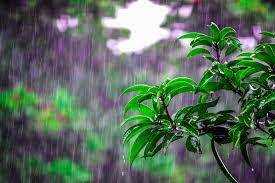

In [8]:
# Load an image
from PIL import Image
from core.common.utils import regularize_image
im = Image.open('./assets/demo_files/rain_on_tree.jpg')
im

In [11]:
# Generate audio
audio_wave = inference_tester.inference(
                xtype = ['audio'],
                condition = [im],
                condition_types = ['image'],
                scale = 7.5,
                n_samples = 1, 
                ddim_steps = 50)[0]

# Play audio
from IPython.display import Audio
Audio(audio_wave.squeeze(), rate=16000)

Data shape for DDIM sampling is [[1, 8, 256, 16]], eta 0.0


DDIM Sampler: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.49it/s]


<a id='AudioToImage'></a>
# Audio To Image
### [Back to Menu](#ContentList)

In [39]:
# Load input audio andplay
import torchaudio
import torch
from IPython.display import Audio
pad_time = 10.23

path = './assets/demo_files/wind_chimes.wav'

audio_wavs, sr = torchaudio.load(path)
audio_wavs = torchaudio.functional.resample(waveform=audio_wavs, orig_freq=sr, new_freq=16000).mean(0)[:int(16000 * pad_time)]
padding = torch.zeros([int(16000 * pad_time) - audio_wavs.size(0)])
audio_wavs = torch.cat([audio_wavs, padding], 0)

from IPython.display import Audio
Audio(path, rate=16000)


Data shape for DDIM sampling is [[1, 4, 32, 32]], eta 0.0


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 13.79it/s]


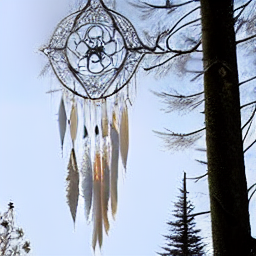

In [41]:
import torch

# Generate image
images = inference_tester.inference(
                xtype = ['image'],
                condition = [audio_wavs],
                condition_types = ['audio'],
                scale = 7.5,
                image_size = 256,
                ddim_steps = 50)
images[0][0]

<a id='TextToVideo'></a>
# Text To Video
### [Back to Menu](#ContentList)

In [48]:
# Give A Prompt
prompt = 'a beautiful waterfall.'

n_samples = 1
outputs = inference_tester.inference(
                ['video'],
                condition = [prompt],
                condition_types = ['text'],
                n_samples = 1,
                image_size = 256,
                ddim_steps = 50,
                num_frames = 8,
                scale = 7.5)

video = outputs[0][0]

Data shape for DDIM sampling is [[1, 4, 8, 32, 32]], eta 0.0


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:22<00:00,  2.18it/s]


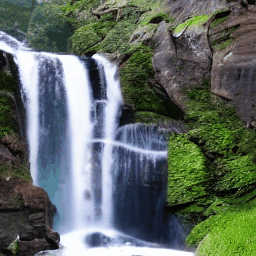

In [49]:
# Visual video as gif
from PIL import Image
frame_one = video[0]
path = "./generated_text2video.gif"
frame_one.save(path, format="GIF", append_images=video[1:],
               save_all=True, duration=2000/len(video), loop=0)

from IPython import display 
from IPython.display import Image
Image(data=open(path,'rb').read(), format='png')

<a id='VideoToText'></a>
# Video To Text
### [Back to Menu](#ContentList)

In [3]:
# Load a video, note that it is best to input video below 10s
from core.common.utils import load_video

video_path = './assets/demo_files/cloud.mp4'
video = load_video(video_path, sample_duration=10.0, num_frames=8)

from IPython.display import Video
Video(video_path)

In [3]:
text = inference_tester.inference(
                xtype = ['text'],
                condition = [video],
                condition_types = ['video'],
                n_samples = 4, 
                scale = 7.5,)
text[0]

Data shape for DDIM sampling is [[4, 768]], eta 0.0


DDIM Sampler: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:04<00:00, 11.10it/s]


['blowing cloud over clouds, cloudy sky',
 'rain clouds gather through fog, cloudy skies and foggy sky, in heavy <unk>.',
 'waterstorm in clear snow.',
 'a stormpour is cloudy blowing through snow']

<a id='TextImageAudioToImage'></a>
#  Text + Audio To Image

### [Back to Menu](#ContentList)

In [67]:
# Load Audio Inputs
import torchaudio
import torch
from IPython.display import Audio

path = './assets/demo_files/sea_waves.wav'

audio_wavs, sr = torchaudio.load(path)
audio_wavs = torchaudio.functional.resample(waveform=audio_wavs, orig_freq=sr, new_freq=16000).mean(0)[:int(16000 * 10.23)]
Audio(audio_wavs.squeeze(), rate=16000)


In [68]:
# Give A Prompt
prompt = 'dawn, dawn scenery, sunset, beautiful lighting.'


Data shape for DDIM sampling is [[1, 4, 32, 32]], eta 0.0


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.18it/s]


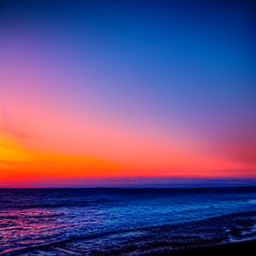

In [72]:
# Generate image
# Mix weight here is the weighting ratio of the condition inputs

n_samples = 1
images = inference_tester.inference(
                ['image'],
                condition = [audio_wavs, prompt],
                condition_types = ['audio', 'text'],
                n_samples = n_samples,
                image_size = 256,
                mix_weight = {'audio': 1, 'text': 2}, )

images[0][0]

<a id='TextToImageText'></a>
#  Text To Image + Text

### [Back to Menu](#ContentList)

In [39]:
# Give A Prompt
prompt = 'deep diving in coral reef underwater.'

outputs = inference_tester.inference(
                ['image', 'text'],
                condition = [prompt],
                condition_types = ['text'],
                n_samples = 1,
                image_size = 256)

image, text = outputs

Data shape for DDIM sampling is [[1, 4, 32, 32], [1, 768]], eta 0.0


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:08<00:00,  6.15it/s]


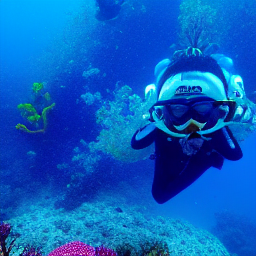

In [40]:
image[0]

In [41]:
text[0]

'blue girl diving on the beach blue water.'

<a id='TextToVideoAudio'></a>
#  Text To Video + Audio

### [Back to Menu](#ContentList)

In [28]:
# Give A Prompt
prompt = 'walking inside a beautiful forest, nature, birds.'


n_samples = 1
outputs = inference_tester.inference(
                ['video', 'audio'],
                condition = [prompt],
                condition_types = ['text'],
                n_samples = 1,
                image_size = 256,
                ddim_steps = 50,
                num_frames = 8,
                scale = 7.5)


Data shape for DDIM sampling is [[1, 4, 8, 32, 32], [1, 8, 256, 16]], eta 0.0


DDIM Sampler: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:58<00:00,  1.17s/it]


In [30]:
video, audio_wave = outputs

from IPython.display import Audio
Audio(audio_wave[0].squeeze(), rate=16000)

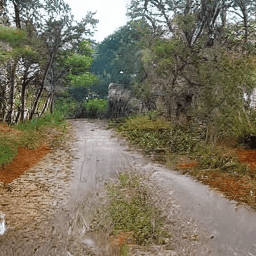

In [31]:
# Visual video as gif
video = video[0]
from PIL import Image
frame_one = video[0]
path = "./generated_video.gif"
frame_one.save(path, format="GIF", append_images=video[1:],
               save_all=True, duration=2000/len(video), loop=0)

from IPython import display 
from IPython.display import Image
Image(data=open(path,'rb').read(), format='png')

In [ ]:
from core.models.model_module_infer import model_module

# 只做“编码→t-SNE”，只加载 encoders 权重就够了
inference_tester = model_module(
    data_dir='checkpoints/',                 # 放权重的目录
    pth=['CoDi_encoders.pth'],               # 只填 encoders；要生成再把 3 个 diffuser 一起填上
    fp16=False                               # 如果下的是 fp16 权重就设 True
).cuda().eval()


c:\Anaconda\envs\multi-dann\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(



#######################
# Running in eps mode #
#######################

making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


AttributeError: CLIPTokenizer has no attribute encoder

: 

In [ ]:
import torch, numpy as np
from pathlib import Path
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
def _l2n(x): return torch.nn.functional.normalize(x, dim=-1)

# —— 根据你 notebook 里模型的实际字段名做绑定（示例名，按需改）——
txt_enc  = getattr(model, 'text_encoder',  None)
img_enc  = getattr(model, 'vision_encoder',None)
aud_enc  = getattr(model, 'audio_encoder', None)
vid_enc  = getattr(model, 'video_encoder', None)

txt_proj = getattr(model, 'text_projector',   None)
img_proj = getattr(model, 'vision_projector', None)
aud_proj = getattr(model, 'audio_projector',  None)
vid_proj = getattr(model, 'video_projector',  None)

# —— 文本 ——（若模型自带 tokenizer/encode 接口，优先用；否则走你 notebook 中已有的封装）
def encode_text(list_of_str):
    if hasattr(txt_enc, 'encode'):
        z = txt_enc.encode(list_of_str).to(device)
    else:
        # 按你实际的 tokenizer / forward 字段名替换
        toks = model.text_tokenizer(list_of_str).to(device)
        z = txt_enc(**toks).pooler_output
    if txt_proj: z = txt_proj(z)
    return _l2n(z)

# —— 图像 ——（用你 notebook 里已经用过的 transforms/预处理）
from PIL import Image
import torchvision.transforms as T
_img_tf = T.Compose([T.Resize(256), T.CenterCrop(256), T.ToTensor()])

def encode_image(paths):
    outs = []
    for p in map(Path, paths):
        x = _img_tf(Image.open(p).convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            f = img_enc(x) if callable(img_enc) else img_enc.encode_image(x)
            if isinstance(f, (list, tuple)): f = f[0]
            if img_proj: f = img_proj(f)
            outs.append(_l2n(f))
    return torch.cat(outs, 0)

# —— 音频 ——（统一采样率与时长会更稳）
import torchaudio
def encode_audio(paths, target_sr=16000, seconds=10.0):
    outs = []
    T_len = int(target_sr * seconds)
    for p in map(Path, paths):
        wav, sr = torchaudio.load(str(p))
        wav = torchaudio.functional.resample(wav.mean(0, keepdim=True), sr, target_sr)
        if wav.size(-1) >= T_len: wav = wav[..., :T_len]
        else: wav = torch.nn.functional.pad(wav, (0, T_len - wav.size(-1)))
        wav = wav.to(device)
        with torch.no_grad():
            f = aud_enc(wav) if callable(aud_enc) else aud_enc.encode_audio(wav)
            if isinstance(f, (list, tuple)): f = f[0]
            if aud_proj: f = aud_proj(f)
            outs.append(_l2n(f))
    return torch.cat(outs, 0)

# —— 视频 ——（按你 notebook 的视频读取方式来：decord/opencv 等）
def encode_video(paths, frames=8):
    outs = []
    for p in map(Path, paths):
        # TODO: 用你已有的抽帧函数替换，得到 (1, T, C, H, W)
        video_tensor = load_video_tensor(str(p), num_frames=frames).to(device)
        with torch.no_grad():
            f = vid_enc(video_tensor) if callable(vid_enc) else vid_enc.encode_video(video_tensor)
            if isinstance(f, (list, tuple)): f = f[0]
            if vid_proj: f = vid_proj(f)
            outs.append(_l2n(f))
    return torch.cat(outs, 0)

# —— 准备你的样本：把文件路径/文本替换成你的数据 —— 
text_emb = encode_text(["a dog running", "a cat on sofa", "a piano solo"])
img_emb  = encode_image(["dog.jpg", "cat.jpg"])
aud_emb  = encode_audio(["bark.wav", "meow.wav"])
# vid_emb  = encode_video(["clip1.mp4", "clip2.mp4"])

# —— 合并到同一矩阵并 t-SNE —— 
all_embs = [x for x in [text_emb, img_emb, aud_emb] if x is not None and x.nelement() > 0]
X  = torch.cat(all_embs, 0).detach().cpu().numpy()
ys = (["text"] * len(text_emb) + ["image"] * len(img_emb) + ["audio"] * len(aud_emb))

tsne = TSNE(n_components=2, perplexity=30, metric='cosine', learning_rate='auto', init='pca', random_state=0)
Z = tsne.fit_transform(X)

# —— 可视化 —— 
mods = sorted(set(ys))
for m in mods:
    idx = [i for i, yy in enumerate(ys) if yy == m]
    plt.scatter(Z[idx,0], Z[idx,1], label=m, s=16, alpha=0.85)
plt.legend(); plt.title("t-SNE of CoDi shared embeddings"); plt.show()
